## Forman-Ricci Curvature Analysis for Undirected Networks

This Jupyter Notebook explores the relationship between Forman-Ricci curvature and various centrality measures in different undirected network models, alongside dynamic SIR modeling. The computation of Forman Ricci Curvature for Undirected Networks is inspired by the implementation found [here](https://github.com/lehaifeng/GeoNetAnalysis/blob/master/GraphRicciCurvature-master/GraphRicciCurvature/FormanRicci.py) and the [original paper: Forman curvature for complex networks](https://arxiv.org/pdf/1603.00386v1).

### Network Models

The notebook generates four types of undirected network models:
1. **Erdős-Rényi Model:** Random graph with \( n = 1000 \) nodes and edge probability \( p = 0.003 \).
2. **Watts-Strogatz Model:** Small-world network with \( n = 1000 \) nodes, each connected to \( k = 5 \) nearest neighbors and rewiring probability \( p = 0.5 \).
3. **Power-law Cluster Model:** Scale-free network with \( n = 1000 \) nodes, \( m = 3 \) edges added for each new node, and probability \( p = 0.05 \) of adding a triangle.
4. **Barabási-Albert Model:** Scale-free network with \( n = 1000 \) nodes and \( m = 3 \) edges added for each new node.

### Forman-Ricci Curvature

Forman-Ricci curvature is computed for each edge in the network using the following steps:
1. Calculate the edge curvature based on the adjacent faces and parallel neighbors.
2. Compute the average node curvature from the adjacent edge curvatures.

### Visualizations

Four types of visualizations are generated to analyze the correlation between Forman-Ricci curvature and centrality measures:
1. **Forman-Ricci Curvature Distribution:** Displays the curvature distribution for each network model.
2. **Forman-Ricci Curvature vs. Node Degree:** Explores the relationship between curvature and node degree.
3. **Forman-Ricci Curvature vs. Clustering Coefficient:** Analyzes how curvature correlates with clustering coefficients.
4. **Forman-Ricci Curvature vs. Betweenness Centrality:** Examines the connection between curvature and betweenness.

Each visualization is plotted for the four network models, and the Pearson correlation coefficient is displayed in the plot title.

### SIR Dynamics with Forman-Ricci Curvature

This notebook extends the traditional SIR model to incorporate Forman-Ricci curvature. The dynamics of the SIR model are simulated across all four network types, considering the curvature-adjusted transmission rates. Key components:
1. **SIR Model:** Includes compartments \(S\), \(I\), and \(R\), with transmission rates adjusted using \( \beta_{ij} = \beta_0 \cdot \exp(F(e)) \).
2. **Compartment Visualization:** Subplots are generated to display \(S\), \(I\), and \(R\) dynamics over time for varying \(\beta_0\).

### Traditional SIR Model Dynamics

Additionally, a baseline SIR model is implemented for comparison:
1. Compartment dynamics (\(S\), \(I\), and \(R\)) are simulated for a population of \(N = 1000\).
2. Subplots display the dynamics for different infection rates.

The implementation offers comprehensive insights into the role of Forman-Ricci curvature in network dynamics and epidemiology, demonstrating its relevance across multiple network structures.

In [1]:
# Libraries and Setup
import sys
import os
sys.path.append(os.path.abspath('..'))  
from frc_lib.undirected_frc import FormanRicci
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.integrate import odeint
# Set seed for reproducibility
np.random.seed(42)

In [2]:
# Create graphs for four undirected networks:
n = 1000 # Number of nodes in the networks

# Erdős-Rényi graph
p_er = 0.003
G_er = nx.erdos_renyi_graph(n, p_er)

# Watts-Strogatz graph
k_ws = 5
p_ws = 0.5
G_ws = nx.watts_strogatz_graph(n, k_ws, p_ws)

# Power-law cluster graph
m_plc = 3
p_plc = 0.05
G_plc = nx.powerlaw_cluster_graph(n, m_plc, p_plc)

# Barabási-Albert graph
m_ba = 3
G_ba = nx.barabasi_albert_graph(n, m_ba)

Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.


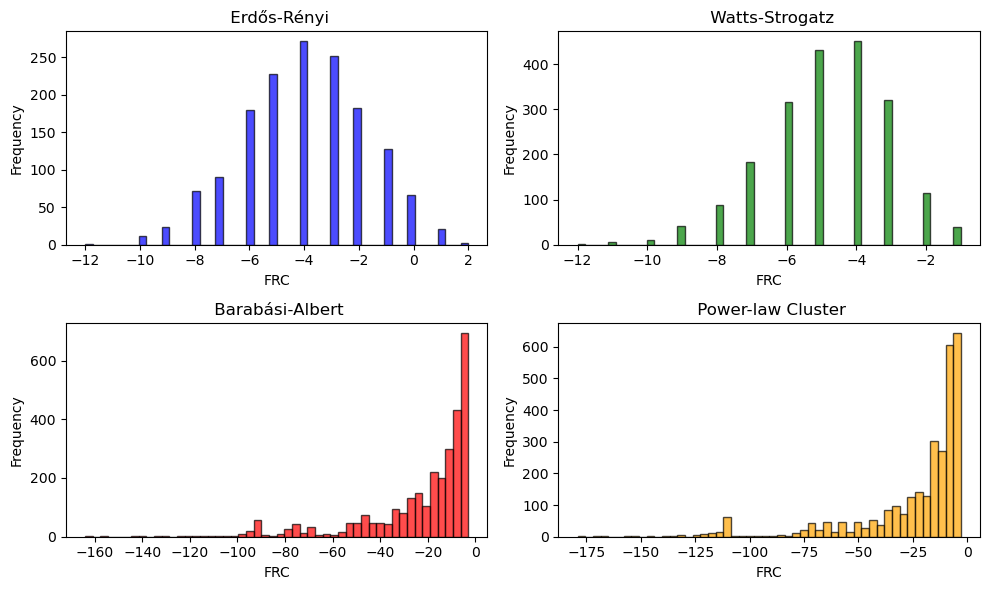

In [3]:
def plot_frc_distribution(G, model_name, ax, color):
    fr = FormanRicci(G)
    G_with_curvature = fr.compute_ricci_curvature()

    # Extract Forman-Ricci curvature values for all edges
    edge_curvatures = [G_with_curvature[u][v]['formanCurvature'] for u, v in G_with_curvature.edges()]

    # Plot histogram of Forman-Ricci curvature values with distinct color
    ax.hist(edge_curvatures, bins=50, alpha=0.7, color=color, edgecolor='black')
    ax.set_title(f' {model_name}')
    ax.set_xlabel('FRC')
    ax.set_ylabel('Frequency')
    #ax.grid(True)

# Plotting the Forman-Ricci Curvature distribution for each network with different colors
fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi=100)

plot_frc_distribution(G_er, "Erdős-Rényi", axs[0, 0], color='blue')
plot_frc_distribution(G_ws, "Watts-Strogatz", axs[0, 1], color='green')
plot_frc_distribution(G_ba, "Barabási-Albert", axs[1, 0], color='red')
plot_frc_distribution(G_plc, "Power-law Cluster", axs[1, 1], color='orange')

plt.tight_layout()
plt.show()

In [4]:
def plot_curvature_vs_degree(G, model_name, ax):
    fr = FormanRicci(G)
    G_with_curvature = fr.compute_ricci_curvature()

    node_degrees = [G_with_curvature.degree(n) for n in G_with_curvature.nodes()]
    node_curvatures = [G_with_curvature.nodes[n]["formanCurvature"] for n in G_with_curvature.nodes()]

    corr, _ = pearsonr(node_curvatures, node_degrees)

    ax.scatter(node_curvatures, node_degrees, alpha=0.6, edgecolors='w', s=80, color='brown')
    ax.set_title(f'{model_name}\nR: {corr:.2f}')
    ax.set_xlabel('FRC')
    ax.set_ylabel('Node Degree')
    #ax.grid(True)

In [5]:
def plot_curvature_vs_clustering(G, model_name, ax):
    fr = FormanRicci(G)
    G_with_curvature = fr.compute_ricci_curvature()

    clustering_coeffs = nx.clustering(G_with_curvature)
    node_curvatures = [G_with_curvature.nodes[n]["formanCurvature"] for n in G_with_curvature.nodes()]

    clustering_values = [clustering_coeffs[n] for n in G_with_curvature.nodes()]
    corr, _ = pearsonr(node_curvatures, clustering_values)

    ax.scatter(node_curvatures, clustering_values, alpha=0.6, edgecolors='w', s=80)
    ax.set_title(f'{model_name:}\nR: {corr:.2f}')
    ax.set_xlabel('FRC')
    ax.set_ylabel('Clustering Coefficient')
    #ax.grid(True)

In [6]:
def plot_curvature_vs_betweenness(G, model_name, ax):
    fr = FormanRicci(G)
    G_with_curvature = fr.compute_ricci_curvature()

    betweenness_centrality = nx.betweenness_centrality(G_with_curvature)
    node_curvatures = [G_with_curvature.nodes[n]["formanCurvature"] for n in G_with_curvature.nodes()]

    betweenness_values = [betweenness_centrality[n] for n in G_with_curvature.nodes()]
    corr, _ = pearsonr(node_curvatures, betweenness_values)

    ax.scatter(node_curvatures, betweenness_values, alpha=0.6, edgecolors='w', s=80, color='green')
    ax.set_title(f'{model_name}\nR: {corr:.2f}')
    ax.set_xlabel('FRC')
    ax.set_ylabel('Betweenness Centrality')
    #ax.grid(True)

Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.


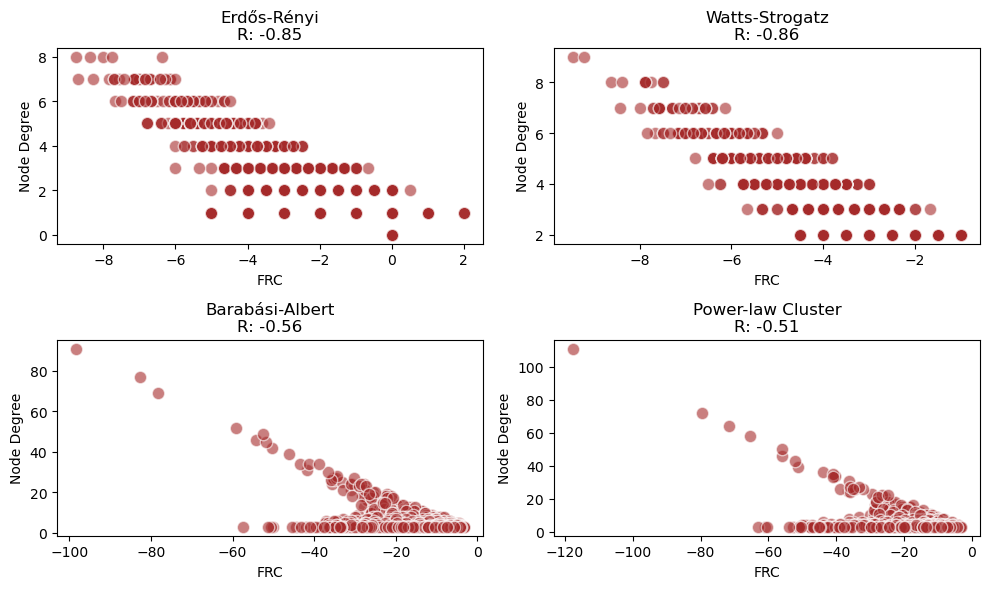

In [7]:
# Plotting of curvature_vs_degree
fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi = 100)

plot_curvature_vs_degree(G_er, "Erdős-Rényi", axs[0, 0])
plot_curvature_vs_degree(G_ws, "Watts-Strogatz", axs[0, 1])
plot_curvature_vs_degree(G_ba, "Barabási-Albert", axs[1, 0])
plot_curvature_vs_degree(G_plc, "Power-law Cluster", axs[1, 1])

plt.tight_layout()

# Save the figure to the 'images' folder
#fig.savefig('images/curvature_vs_degree.png')

plt.show()

Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.


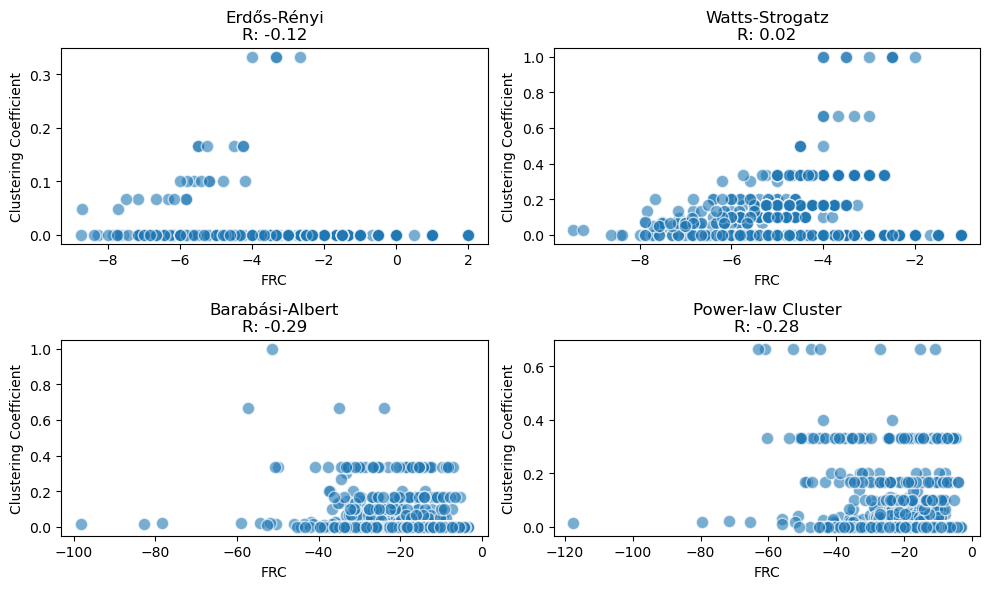

In [8]:
# Plotting for curvature_vs_clustering
fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi = 100)

plot_curvature_vs_clustering(G_er, "Erdős-Rényi", axs[0, 0])
plot_curvature_vs_clustering(G_ws, "Watts-Strogatz", axs[0, 1])
plot_curvature_vs_clustering(G_ba, "Barabási-Albert", axs[1, 0])
plot_curvature_vs_clustering(G_plc, "Power-law Cluster", axs[1, 1])
plt.tight_layout()
# Save the figure to the 'images' folder
#fig.savefig('images/curvature_vs_clustering.png')
plt.show()

Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.
Forman curvature computation done.


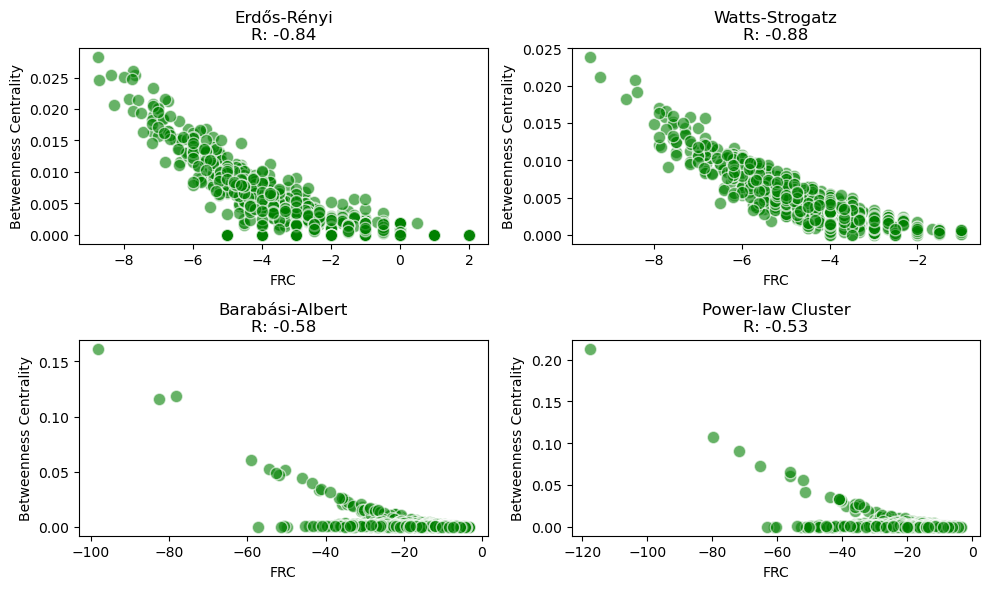

In [9]:
# Plotting of curvature_vs_betweenness
fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi = 100)

plot_curvature_vs_betweenness(G_er, "Erdős-Rényi", axs[0, 0])
plot_curvature_vs_betweenness(G_ws, "Watts-Strogatz", axs[0, 1])
plot_curvature_vs_betweenness(G_ba, "Barabási-Albert", axs[1, 0])
plot_curvature_vs_betweenness(G_plc, "Power-law Cluster", axs[1, 1])
plt.tight_layout()
# Save the figure to the 'images' folder
#fig.savefig('images/curvature_vs_betweenness.png')
#plt.tight_layout()
plt.show()

### SIR Dynamics with Undirected FRC across the Four Models

In [10]:
# Parameters
gamma = 0.1  # Recovery rate (constant)
beta_values = [0.1, 0.3, 0.5, 0.7]  # Different beta values to simulate
def sir_model(y, t, beta, gamma, B, n):
    S, I, R = y[:n], y[n:2*n], y[2*n:]
    infection_force = B @ I
    dSdt = -S * infection_force
    dIdt = S * infection_force - gamma * I
    dRdt = gamma * I
    return np.concatenate([dSdt, dIdt, dRdt])

In [11]:
def simulate_sir_model(G, model_name="Network"):
    # Compute FRC
    fr = FormanRicci(G)
    G = fr.compute_ricci_curvature()

    # Map node labels to indices
    node_list = list(G.nodes())
    node_to_index = {node: idx for idx, node in enumerate(node_list)}
    n = len(node_list)

    # Initial conditions
    S0 = np.full(n, 0.9)
    I0 = np.full(n, 0.1)
    R0 = np.zeros(n)
    initial_conditions = np.concatenate([S0, I0, R0])

    # Time vector
    t = np.linspace(0, 100, 500)

    # Plot setup
    fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi=100)
    axs = axs.flatten()

    for idx, beta in enumerate(beta_values):
        # Transmission matrix
        B = np.zeros((n, n))
        for u, v in G.edges():
            frc = G[u][v].get('formanCurvature', 0.0)
            i, j = node_to_index[u], node_to_index[v]
            B[i, j] = beta * np.exp(frc)
            B[j, i] = beta * np.exp(frc)

        np.fill_diagonal(B, 0)

        # Integrate SIR
        sol = odeint(sir_model, initial_conditions, t, args=(beta, gamma, B, n))
        S, I, R = sol[:, :n], sol[:, n:2*n], sol[:, 2*n:]
        I_mean = np.mean(I, axis=1)
        I_total = I_mean * n

        axs[idx].plot(t, I_total, label="Infected", color='r')
        axs[idx].set_title(f'{model_name} (β = {beta})', fontsize=10)
        axs[idx].set_xlabel('Time', fontsize=8)
        axs[idx].set_ylabel('Number Infected', fontsize=8)
        axs[idx].legend(fontsize=7)
        axs[idx].tick_params(labelsize=7)

    #plt.suptitle(f'SIR Dynamics on {model_name} with FRC-Adjusted Transmission Rates', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


Forman curvature computation done.


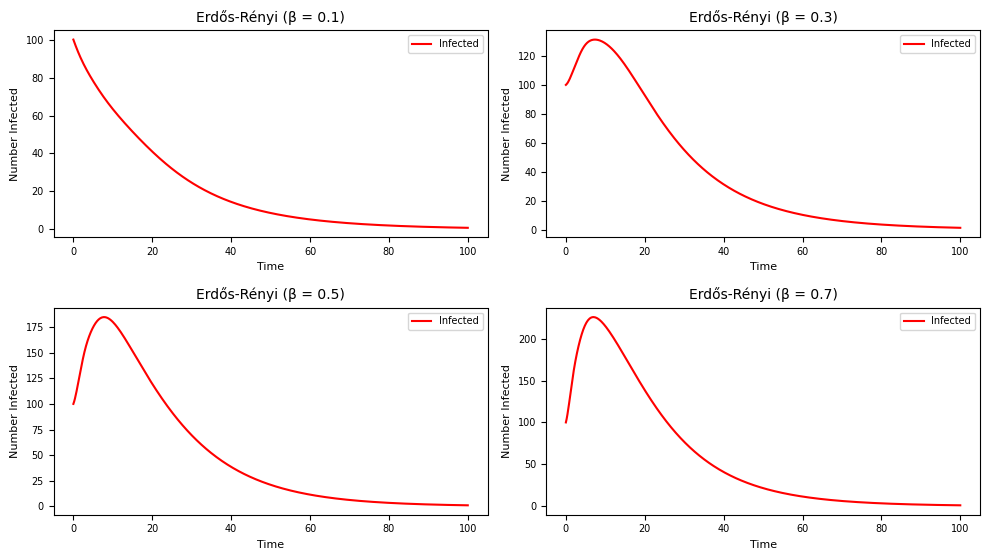

In [12]:
# Simulate the SIR model for each network separately
simulate_sir_model(G_er, model_name="Erdős-Rényi")

Forman curvature computation done.


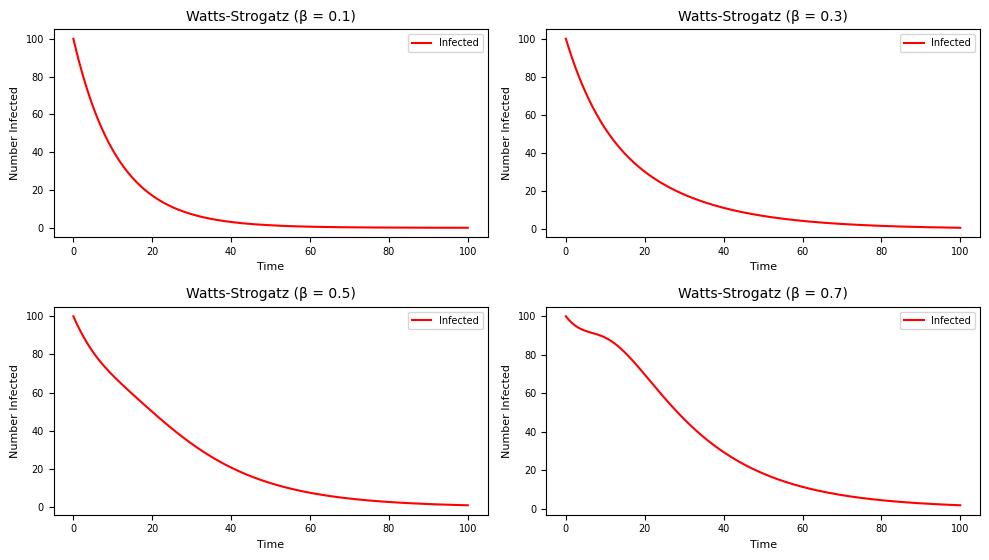

In [13]:
simulate_sir_model(G_ws, "Watts-Strogatz")

Forman curvature computation done.


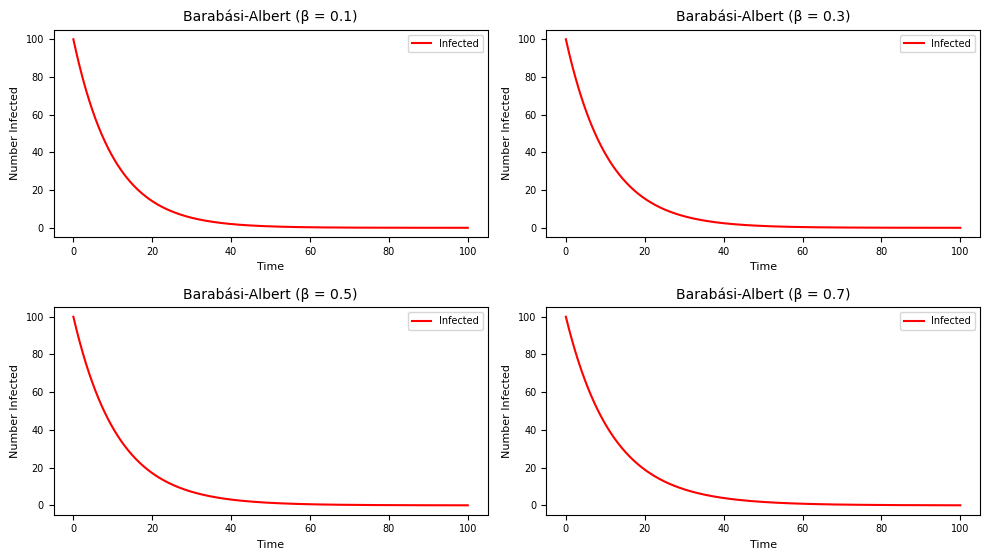

In [14]:
simulate_sir_model(G_ba, "Barabási-Albert")

Forman curvature computation done.


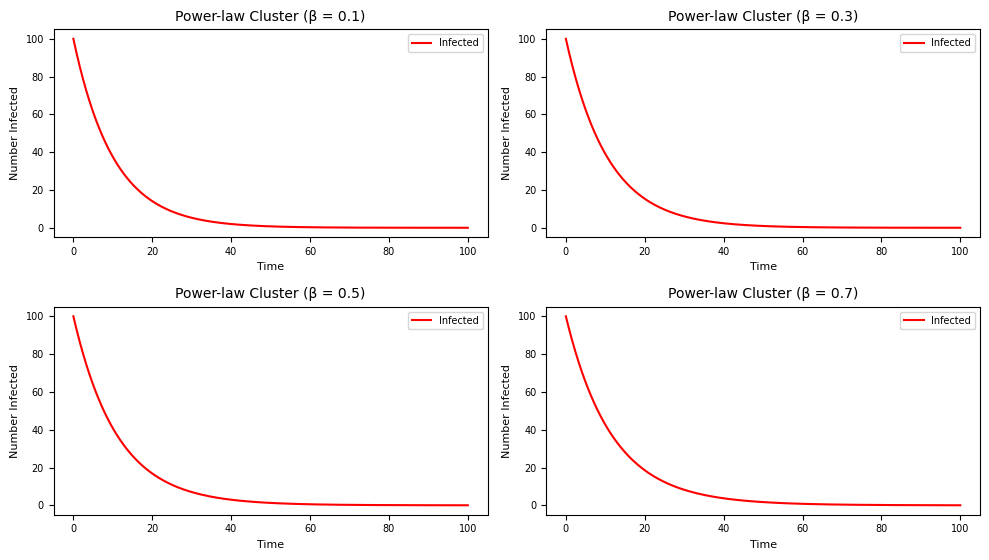

In [15]:
simulate_sir_model(G_plc, "Power-law Cluster")

In [16]:
# ---- Simulation and Plotting Function ----
def simulate_sir_model(G, model_name="Network"):
    # Compute Forman-Ricci curvature
    fr = FormanRicci(G)
    G = fr.compute_ricci_curvature()

    # Map node labels to indices for consistent indexing
    node_list = list(G.nodes())
    node_to_index = {node: idx for idx, node in enumerate(node_list)}
    n = len(node_list)

    # Initial conditions
    S0 = np.full(n, 0.9)
    I0 = np.full(n, 0.1)
    R0 = np.zeros(n)
    initial_conditions = np.concatenate([S0, I0, R0])
    t = np.linspace(0, 100, 500)

    # Set up subplots
    fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi=100)
    axs = axs.flatten()

    for idx, beta in enumerate(beta_values):
        # Create transmission matrix B
        B = np.zeros((n, n))
        for u, v in G.edges():
            frc = G[u][v].get('formanCurvature', 0.0)
            i, j = node_to_index[u], node_to_index[v]
            B[i, j] = beta * np.exp(frc)
            B[j, i] = beta * np.exp(frc)  # Undirected

        np.fill_diagonal(B, 0)

        # Solve ODE
        sol = odeint(sir_model, initial_conditions, t, args=(beta, gamma, B, n))
        S, I, R = sol[:, :n], sol[:, n:2*n], sol[:, 2*n:]
        S_mean = np.mean(S, axis=1) * n
        I_mean = np.mean(I, axis=1) * n
        R_mean = np.mean(R, axis=1) * n

        # Plot all three compartments
        axs[idx].plot(t, S_mean, label='Susceptible', color='blue')
        axs[idx].plot(t, I_mean, label='Infected', color='red')
        axs[idx].plot(t, R_mean, label='Recovered', color='green')

        axs[idx].set_title(f'{model_name} (β = {beta})', fontsize=10)
        axs[idx].set_xlabel('Time', fontsize=9)
        axs[idx].set_ylabel('Population', fontsize=9)
        axs[idx].legend(fontsize=7)
        axs[idx].tick_params(labelsize=8)
        #axs[idx].grid(True)

    #plt.suptitle(f'SIR Dynamics on {model_name} Network with FRC', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


Forman curvature computation done.


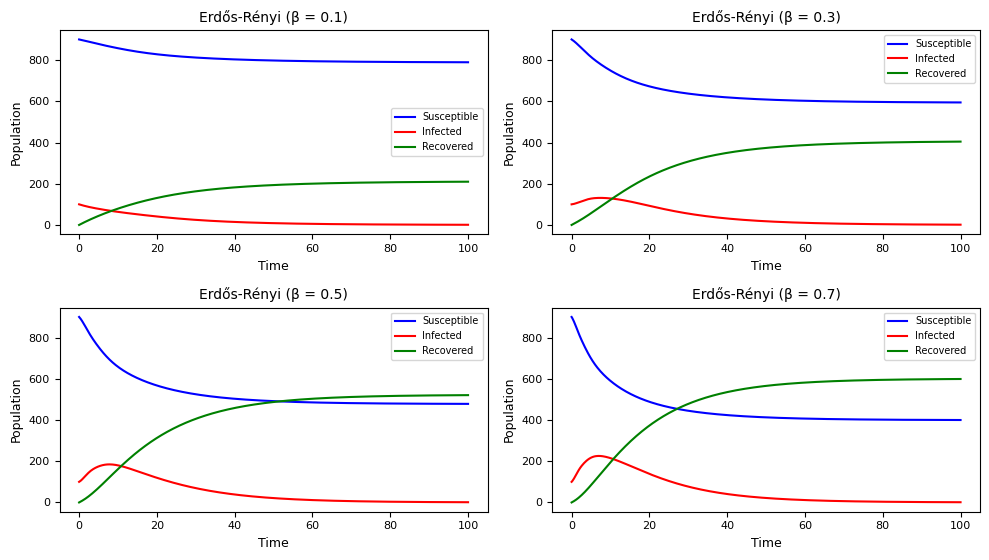

In [17]:
# Simulate the SIR model for the Erdős-Rényi network separately
simulate_sir_model(G_er, "Erdős-Rényi")

Forman curvature computation done.


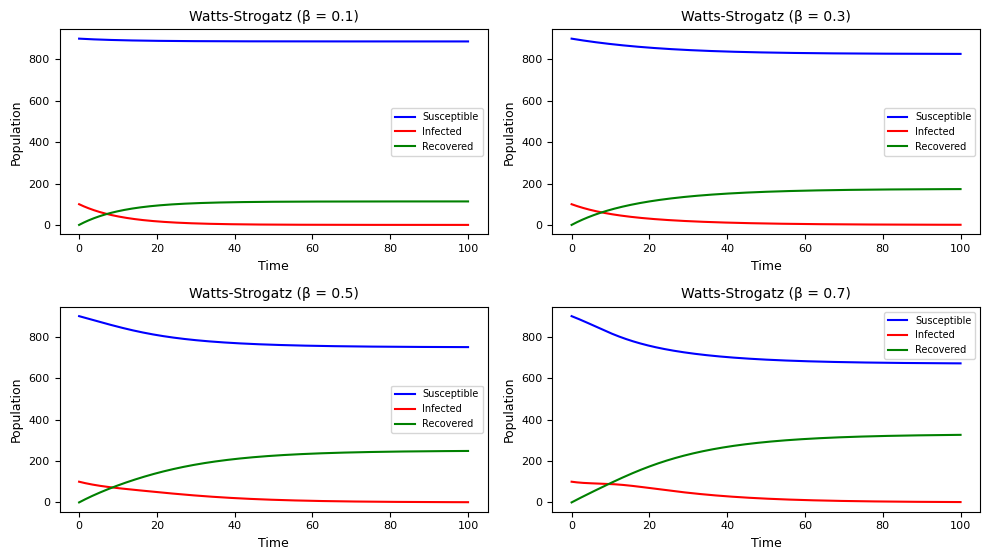

In [18]:
simulate_sir_model(G_ws, "Watts-Strogatz")

Forman curvature computation done.


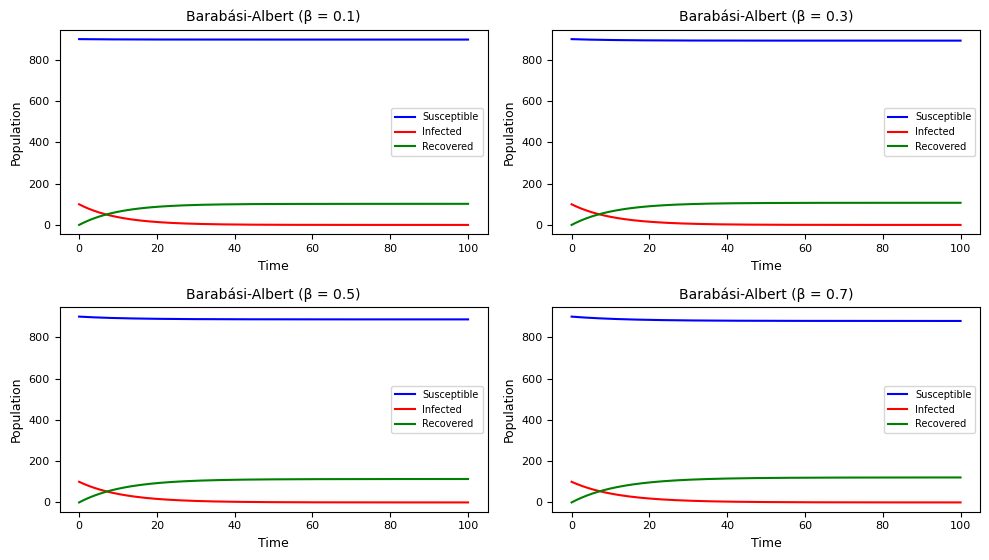

In [19]:
simulate_sir_model(G_ba, "Barabási-Albert")

Forman curvature computation done.


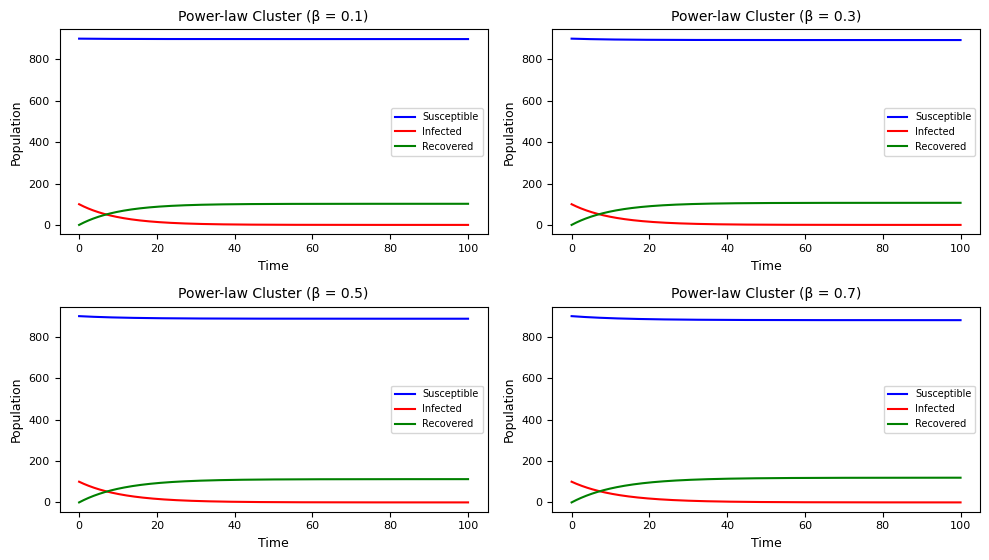

In [20]:
simulate_sir_model(G_plc, "Power-law Cluster")

### Dynamics of Traditional SIR Model

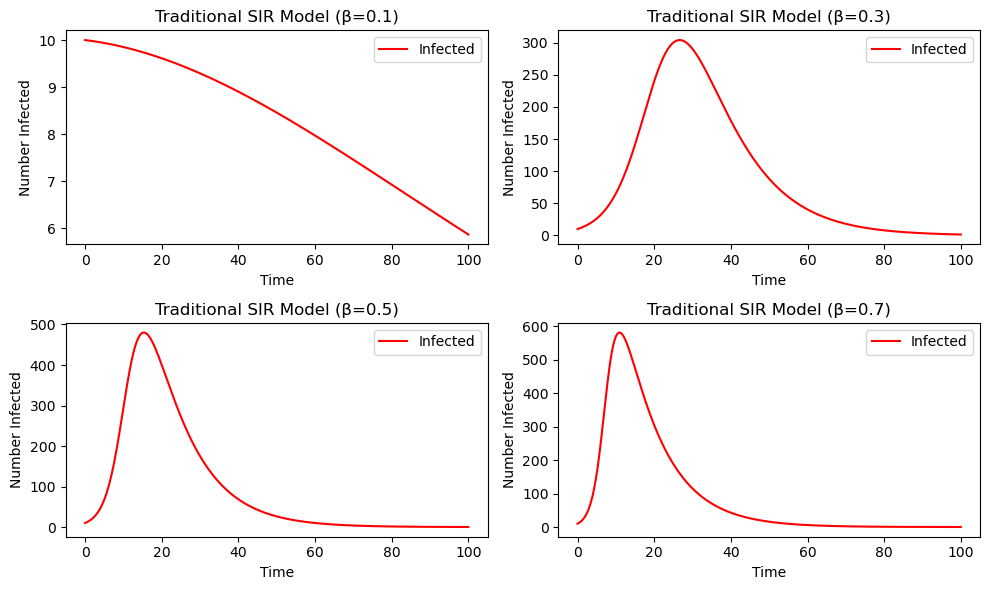

In [21]:
# Define the traditional SIR model
# dS/dt = -beta_0 * S * I / N
# dI/dt = beta_0 * S * I / N - gamma * I
# dR/dt = gamma * I
def sir_derivatives(y, t, N, beta_0, gamma):
    S, I, R = y
    dSdt = -beta_0 * S * I / N
    dIdt = beta_0 * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# Function to solve the traditional SIR model using odeint
def traditional_SIR_model(N, beta_0, gamma, T, dt):
    # Initial conditions: S0, I0, R0
    S0 = 0.99 * N
    I0 = 0.01 * N
    R0 = 0.0
    y0 = S0, I0, R0

    # Time points for the integration
    t = np.linspace(0, T, int(T / dt) + 1)

    # Solve the SIR differential equations
    ret = odeint(sir_derivatives, y0, t, args=(N, beta_0, gamma))
    S, I, R = ret.T

    return t, S, I, R

# Plotting function for traditional SIR model
# Plots the infected population for different beta_0 values
def plot_SIR_dynamics_subplots(t, I_t_list, beta_0_values):
    fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi = 100)
    axs = axs.flatten()  # Flatten the array for easy iteration

    for i, (I_t, beta_0) in enumerate(zip(I_t_list, beta_0_values)):
        axs[i].plot(t, I_t, label='Infected', color='red')
        axs[i].set_xlabel('Time')
        axs[i].set_ylabel('Number Infected')
        axs[i].set_title(f'Traditional SIR Model (β={beta_0})')
        axs[i].legend()
        #axs[i].grid(True)

    plt.tight_layout()

    # Save the figure in high resolution (300 dpi)
    #fig.savefig("images/traditional_sir_infected_dynamics_comparison.png", dpi=300)

    plt.show()

# Parameters
beta_0_values = [0.1, 0.3, 0.5, 0.7]
I_t_list = []

# Number of individuals
N = 1000
T = 100  # Total time for the simulation
dt = 0.1  # Time step
gamma = 0.1  # Recovery rate

# Run simulations for different beta_0 values
for beta_0 in beta_0_values:
    t, S_t, I_t, R_t = traditional_SIR_model(N, beta_0, gamma, T, dt)
    I_t_list.append(I_t)

# Plot only the infected population in subplots
plot_SIR_dynamics_subplots(t, I_t_list, beta_0_values)


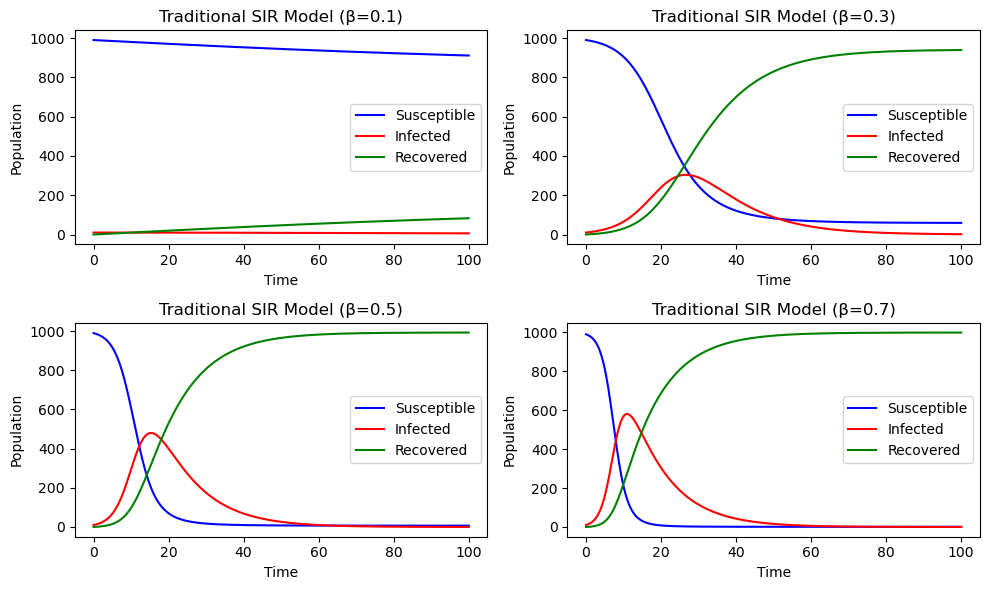

In [22]:
# Plotting function for traditional SIR model
# Plots S, I, R compartments for different beta_0 values
def plot_SIR_dynamics_all_compartments(t, S_t_list, I_t_list, R_t_list, beta_0_values):
    fig, axs = plt.subplots(2, 2, figsize=(10, 6), dpi = 100)
    axs = axs.flatten()  # Flatten the array for easy iteration

    for i, (S_t, I_t, R_t, beta_0) in enumerate(zip(S_t_list, I_t_list, R_t_list, beta_0_values)):
        axs[i].plot(t, S_t, label='Susceptible', color='blue')
        axs[i].plot(t, I_t, label='Infected', color='red')
        axs[i].plot(t, R_t, label='Recovered', color='green')
        axs[i].set_xlabel('Time')
        axs[i].set_ylabel('Population')
        axs[i].set_title(f'Traditional SIR Model (β={beta_0})')
        axs[i].legend()
        #axs[i].grid(True)

    plt.tight_layout()

    # Save the figure in high resolution (300 dpi)
    #fig.savefig("images/traditional_sir_all_compartments_comparison.png", dpi=300)

    plt.show()

# Parameters
beta_0_values = [0.1, 0.3, 0.5, 0.7]
S_t_list, I_t_list, R_t_list = [], [], []

# Number of individuals
N = 1000
T = 100  # Total time for the simulation
dt = 0.1  # Time step
gamma = 0.1  # Recovery rate

# Run simulations for different beta_0 values
for beta_0 in beta_0_values:
    t, S_t, I_t, R_t = traditional_SIR_model(N, beta_0, gamma, T, dt)
    S_t_list.append(S_t)
    I_t_list.append(I_t)
    R_t_list.append(R_t)

# Plot all compartments in subplots
plot_SIR_dynamics_all_compartments(t, S_t_list, I_t_list, R_t_list, beta_0_values)
